In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

In [15]:
np.random.seed(1)
n = 1000

# Age covariate which we set to hold PH
age = np.random.normal(50, 10, n)

# Biomarker covariate which we set to violate PH
biomarker = np.random.normal(100, 15, n)

# Base Weibull survival parameters
base_shape = 2.0
base_scale = 50.0

# age affects scale but not shape, ensuring PH holds for age
# biomarker affects shape, ensuring PH is violated for biomarker
shape_true = base_shape + 0.05 * (biomarker - 100)
shape_true = np.clip(shape_true, 0.1, None) # Keep shape mathematically valid
scale_true = base_scale * np.exp(-0.02 * (age - 50))

# Generate true survival times
U = np.random.uniform(0, 1, n)
true_survival_times = scale_true * (-np.log(U)) ** (1 / shape_true)

# Add random censoring
censoring_times = np.random.uniform(10, 120, n)
observed_times = np.minimum(true_survival_times, censoring_times)
event_observed = (true_survival_times <= censoring_times).astype(int)

# Create the final df
df = pd.DataFrame({
    'time': observed_times,
    'event': event_observed,
    'age': age,
    'blood pressure': biomarker  # example biomarker e.g. blood pressure
})

# fit cox model
cph = CoxPHFitter()
cph.fit(df, duration_col='time', event_col='event')

<lifelines.CoxPHFitter: fitted with 1000 total observations, 330 right-censored observations>


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 1000 total observations, 330 right-censored observations>
         test_name = proportional_hazard_test

---
                     test_statistic      p  -log2(p)
age            km              0.22   0.64      0.65
               rank            0.75   0.39      1.37
blood pressure km            116.99 <0.005     88.16
               rank          126.01 <0.005     94.73



1. Variable 'blood pressure' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'blood pressure' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'blood pressure' using pd.cut, and then specify it in
`strata=['blood pressure', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20h

[[<Axes: xlabel='rank-transformed time\n(p=0.3871)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6392)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0000)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0000)'>]]

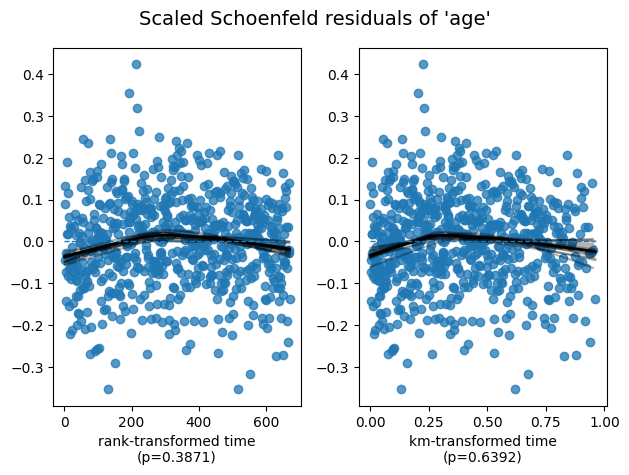

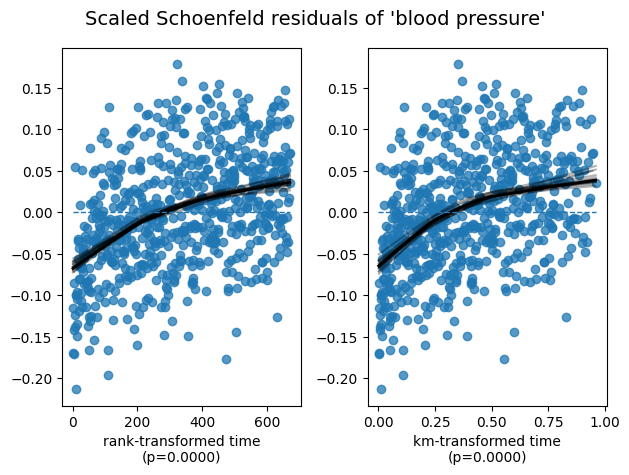

In [17]:
cph.check_assumptions(df, p_value_threshold=0.05, show_plots=True)